# KNN

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
seed = 42

In [4]:
dataset = pd.read_csv("./datasets/thyroid0387_imputed.data", sep = ";", index_col="Unnamed: 0")

In [5]:
numeric_col = dataset.select_dtypes(include = ["int64", "float64"]).columns

scaler = StandardScaler()
dataset[numeric_col] = scaler.fit_transform(dataset[numeric_col])

In [6]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
hypothyroid               572
general_health            435
replacement_therapy       336
binding_protein           324
misc                      221
hyperthyroid              184
antithyroid_treatment      33
Name: count, dtype: int64

In [7]:
dataset.isnull().sum().sort_values(ascending=False)


age                          0
on_thyroxine                 0
ref_WEST                     0
ref_SVI                      0
ref_SVHD                     0
ref_SVHC                     0
ref_STMW                     0
TBG_value                    0
FTI_value                    0
T4U_value                    0
TT4_value                    0
T3_value                     0
TSH_value                    0
sex_M                        0
diagnosis_group              0
diagnosis                    0
psych                        0
hypopituitary                0
tumor                        0
goitre                       0
lithium                      0
query_hyperthyroid           0
query_hypothyroid            0
I131_treatment               0
thyroid_surgery              0
pregnant                     0
sick                         0
on_antithyroid_medication    0
query_on_thyroxine           0
ref_other                    0
dtype: int64

In [8]:
dataset.dropna()["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
hypothyroid               572
general_health            435
replacement_therapy       336
binding_protein           324
misc                      221
hyperthyroid              184
antithyroid_treatment      33
Name: count, dtype: int64

In [9]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,-1.236522,False,False,False,False,False,False,False,True,False,...,-0.071379,-0.049085,-0.055753,0.731246,False,False,False,False,False,True
1,-1.236522,False,False,False,False,False,False,False,False,False,...,0.510487,-0.003203,0.581059,-0.613711,False,False,False,False,False,True
2,-0.600043,False,False,False,False,False,False,False,False,True,...,-0.519746,-1.097706,0.287541,-1.977649,False,False,False,False,False,True
3,-0.865243,False,False,False,False,False,False,False,False,False,...,-0.037285,0.234272,-0.153910,-0.070715,False,False,False,False,False,True
4,-1.077402,False,False,False,False,False,False,False,False,False,...,-0.459299,-0.862097,0.214125,1.200575,False,False,False,False,False,True


In [10]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
hypothyroid               572
general_health            435
replacement_therapy       336
binding_protein           324
misc                      221
hyperthyroid              184
antithyroid_treatment      33
Name: count, dtype: int64

In [11]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [12]:
x = dataset.drop(columns=["diagnosis_group", "diagnosis"])
y = dataset["diagnosis_group"]

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [14]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (5985, 28)
X test: (2566, 28)
Y train: (5985,)
Y test: (2566,)


## Model

In [15]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


## Model evaluation

Accuracy: 0.9224473889321901
F1 score: 0.9193187087231977


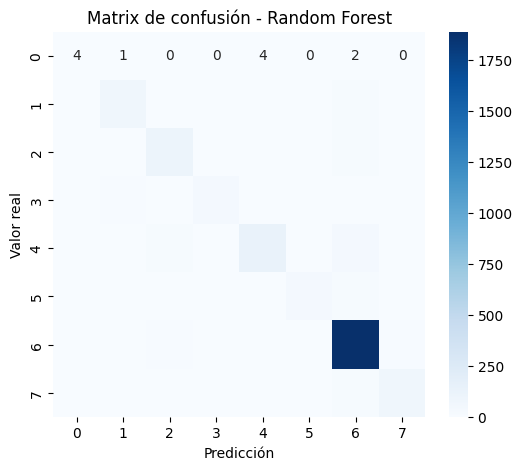

In [16]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - Random Forest')
plt.show()


## Saving model

In [17]:
joblib.dump(knn, "./models_saved/knn.json")

['./models_saved/knn.json']

## Bayesian optimization

Function that will be used during the optimization

In [20]:
def objective(trial):
    params = {
        "p": trial.suggest_int("p", 1, 2),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 30),
        "algorithm": trial.suggest_categorical("algorithm", ["auto", "kd_tree", "brute", "ball_tree"]),
        
        "n_jobs": -1
    }

    model = KNeighborsClassifier(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return f1_score(y_test, y_pred, average = "weighted")

Optimization process

In [21]:
optimization = optuna.create_study(direction = "maximize")
optimization.optimize(objective, n_trials = 100)

[I 2025-04-17 19:31:18,660] A new study created in memory with name: no-name-02606e40-ce13-4ad9-a9bc-966b70b1de80
[I 2025-04-17 19:31:20,171] Trial 0 finished with value: 0.9346607924820451 and parameters: {'p': 1, 'weights': 'uniform', 'n_neighbors': 3, 'algorithm': 'auto'}. Best is trial 0 with value: 0.9346607924820451.
[I 2025-04-17 19:31:22,360] Trial 1 finished with value: 0.8858075095704425 and parameters: {'p': 2, 'weights': 'uniform', 'n_neighbors': 22, 'algorithm': 'ball_tree'}. Best is trial 0 with value: 0.9346607924820451.
[I 2025-04-17 19:31:23,109] Trial 2 finished with value: 0.8913200810934427 and parameters: {'p': 2, 'weights': 'uniform', 'n_neighbors': 20, 'algorithm': 'auto'}. Best is trial 0 with value: 0.9346607924820451.
[I 2025-04-17 19:31:23,480] Trial 3 finished with value: 0.8806828955647341 and parameters: {'p': 2, 'weights': 'uniform', 'n_neighbors': 27, 'algorithm': 'brute'}. Best is trial 0 with value: 0.9346607924820451.
[I 2025-04-17 19:31:23,764] Trial

In [22]:
print(f"Best parameters: {optimization.best_params}")

Best parameters: {'p': 1, 'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'brute'}


In [23]:
knn = KNeighborsClassifier(**optimization.best_params)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

In [24]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

Accuracy: 0.9395946999220577
F1 score: 0.9380493694419438


In [25]:
joblib.dump(knn, "./models_saved/knn_opt.json")

['./models_saved/knn_opt.json']